# Within-Condition Baseline Training — Results

This notebook presents the results of the within-condition baseline training experiment. Seven classifiers are evaluated on binary disease vs. control classification for each of the three neurological conditions (PD, HD, ALS) using subject-level leave-one-out cross-validation (LOSO-CV) with nested hyperparameter tuning.

**Data source:** `experiments/results/{pd,hd,als}_results.json`  
**Training script:** `scripts/run_step2_training.py` → `src/train.py`  
**Run date:** 2026-04-04

Each classifier is evaluated with an aggregate F1 macro score computed over the full concatenated out-of-fold prediction vector. Per-fold F1 is undefined because each outer fold holds out exactly one subject, who belongs to exactly one class.

Each visualisation cell appears twice: a Plotly figure for interactive exploration and a Matplotlib figure exported for the paper.

In [1]:
import sys
import json
from pathlib import Path

sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import polars as pl
from sklearn.metrics import confusion_matrix, f1_score, ConfusionMatrixDisplay

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from features import ALL_FEATURE_COLS

matplotlib.rcParams.update({
    'font.size': 9,
    'font.family': 'serif',
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
})

RESULTS_DIR  = Path('../experiments/results')
PROCESSED    = Path('../data/processed')
FIGURES_PDF = Path('../report/figures/pdf')
FIGURES_PNG = Path('../report/figures/png')
FIGURES_PDF.mkdir(parents=True, exist_ok=True)
FIGURES_PNG.mkdir(parents=True, exist_ok=True)

CONDITIONS   = ['pd', 'hd', 'als']
CLF_NAMES    = ['rf', 'knn', 'svm', 'dt', 'qda', 'xgb', 'lgbm']
CLF_LABELS   = ['RF', 'KNN', 'SVM', 'DT', 'QDA', 'XGBoost', 'LightGBM']
COND_LABELS  = {'pd': 'PD', 'hd': 'HD', 'als': 'ALS'}


In [2]:
# Load results, build summary DataFrames, and extract stored predictions.
results = {}
for cond in CONDITIONS:
    with open(RESULTS_DIR / f'{cond}_results.json') as f:
        results[cond] = json.load(f)

# F1 macro table: rows = classifiers, columns = conditions
f1_rows = []
for clf_name, clf_label in zip(CLF_NAMES, CLF_LABELS):
    row = {'Classifier': clf_label}
    for cond in CONDITIONS:
        row[COND_LABELS[cond]] = results[cond]['classifiers'][clf_name]['f1_macro']
    f1_rows.append(row)

f1_df = pl.DataFrame(f1_rows)

# Modal params table: rows = (condition, classifier)
modal_rows = []
for cond in CONDITIONS:
    n_folds = results[cond]['pool_subjects']
    for clf_name, clf_label in zip(CLF_NAMES, CLF_LABELS):
        clf_res = results[cond]['classifiers'][clf_name]
        params_str = ', '.join(
            f"{k.replace('clf__', '')}={v}"
            for k, v in clf_res['modal_params'].items()
        )
        modal_rows.append({
            'Condition': COND_LABELS[cond],
            'Classifier': clf_label,
            'Modal Params': params_str,
            'Frequency': f"{clf_res['modal_frequency']}/{n_folds}",
        })

modal_df = pl.DataFrame(modal_rows)

# Stored predictions from nested LOSO-CV — exact results, no re-run needed.
y_true_pd  = np.array(results['pd']['classifiers']['rf']['y_true'])
y_pred_pd  = np.array(results['pd']['classifiers']['rf']['y_pred'])
y_true_hd  = np.array(results['hd']['classifiers']['rf']['y_true'])
y_pred_hd  = np.array(results['hd']['classifiers']['rf']['y_pred'])
y_true_als = np.array(results['als']['classifiers']['knn']['y_true'])
y_pred_als = np.array(results['als']['classifiers']['knn']['y_pred'])

# Sanity check: stored lists must reproduce the stored F1 exactly.
assert abs(f1_score(y_true_pd,  y_pred_pd,  average='macro') - results['pd']['classifiers']['rf']['f1_macro'])   < 1e-6
assert abs(f1_score(y_true_hd,  y_pred_hd,  average='macro') - results['hd']['classifiers']['rf']['f1_macro'])   < 1e-6
assert abs(f1_score(y_true_als, y_pred_als, average='macro') - results['als']['classifiers']['knn']['f1_macro']) < 1e-6

print('Pool statistics:')
for cond in CONDITIONS:
    r = results[cond]
    print(f"  {COND_LABELS[cond]}: {r['pool_subjects']} subjects, {r['pool_strides']:,} strides")
print()
print(f1_df)


Pool statistics:
  PD: 23 subjects, 5,738 strides
  HD: 27 subjects, 6,661 strides
  ALS: 21 subjects, 4,467 strides

shape: (7, 4)
┌────────────┬──────────┬──────────┬──────────┐
│ Classifier ┆ PD       ┆ HD       ┆ ALS      │
│ ---        ┆ ---      ┆ ---      ┆ ---      │
│ str        ┆ f64      ┆ f64      ┆ f64      │
╞════════════╪══════════╪══════════╪══════════╡
│ RF         ┆ 0.777711 ┆ 0.89947  ┆ 0.773703 │
│ KNN        ┆ 0.711028 ┆ 0.866928 ┆ 0.875824 │
│ SVM        ┆ 0.719359 ┆ 0.852442 ┆ 0.822133 │
│ DT         ┆ 0.743427 ┆ 0.898026 ┆ 0.732935 │
│ QDA        ┆ 0.640584 ┆ 0.57988  ┆ 0.690544 │
│ XGBoost    ┆ 0.772664 ┆ 0.893711 ┆ 0.785411 │
│ LightGBM   ┆ 0.725111 ┆ 0.870331 ┆ 0.732932 │
└────────────┴──────────┴──────────┴──────────┘


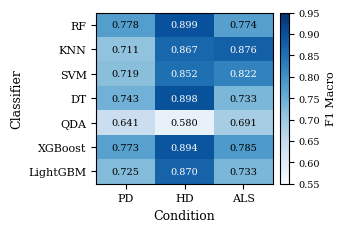

Saved: f1_within_condition_heatmap.pdf / .png


In [3]:
# Build F1 value matrix for plotting.
f1_values = np.array([
    [results[cond]['classifiers'][clf]['f1_macro'] for cond in CONDITIONS]
    for clf in CLF_NAMES
])

# F1 macro performance table — Matplotlib figure for paper (IEEE single-column)
fig, ax = plt.subplots(figsize=(3.5, 2.4))

cmap = plt.cm.Blues
norm = mcolors.Normalize(vmin=0.55, vmax=0.95)

im = ax.imshow(f1_values, cmap=cmap, norm=norm, aspect='auto')

ax.set_xticks(range(len(CONDITIONS)))
ax.set_xticklabels([COND_LABELS[c] for c in CONDITIONS])
ax.set_yticks(range(len(CLF_NAMES)))
ax.set_yticklabels(CLF_LABELS)
ax.set_xlabel('Condition')
ax.set_ylabel('Classifier')

for i in range(len(CLF_NAMES)):
    for j in range(len(CONDITIONS)):
        v = f1_values[i, j]
        text_color = 'white' if norm(v) > 0.65 else 'black'
        ax.text(j, i, f'{v:.3f}', ha='center', va='center',
                fontsize=7, color=text_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('F1 Macro', fontsize=8)
cbar.ax.tick_params(labelsize=7)

fig.tight_layout()
fig.savefig(FIGURES_PDF / 'f1_within_condition_heatmap.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_PNG / 'f1_within_condition_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: f1_within_condition_heatmap.pdf / .png')

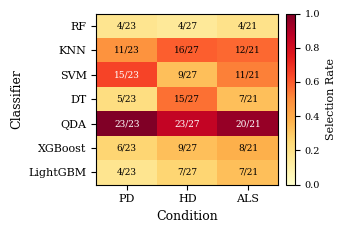

Saved: modal_frequency_heatmap.pdf / .png


In [4]:
# Modal hyperparameter stability — normalised selection rate heatmap for paper
# Normalised rate = modal_frequency / n_folds: how often the plurality combination
# was selected. High rate → stable hyperparameter preference; low rate → many
# equally-performing combinations exist (instability).
freq_values = np.array([
    [
        results[cond]['classifiers'][clf]['modal_frequency'] / results[cond]['pool_subjects']
        for cond in CONDITIONS
    ]
    for clf in CLF_NAMES
])

fig, ax = plt.subplots(figsize=(3.5, 2.4))

cmap_freq = plt.cm.YlOrRd
norm_freq = mcolors.Normalize(vmin=0.0, vmax=1.0)

im = ax.imshow(freq_values, cmap=cmap_freq, norm=norm_freq, aspect='auto')

ax.set_xticks(range(len(CONDITIONS)))
ax.set_xticklabels([COND_LABELS[c] for c in CONDITIONS])
ax.set_yticks(range(len(CLF_NAMES)))
ax.set_yticklabels(CLF_LABELS)
ax.set_xlabel('Condition')
ax.set_ylabel('Classifier')

for i in range(len(CLF_NAMES)):
    for j in range(len(CONDITIONS)):
        v = freq_values[i, j]
        freq = results[CONDITIONS[j]]['classifiers'][CLF_NAMES[i]]['modal_frequency']
        n    = results[CONDITIONS[j]]['pool_subjects']
        text_color = 'white' if norm_freq(v) > 0.65 else 'black'
        ax.text(j, i, f'{freq}/{n}', ha='center', va='center',
                fontsize=6.5, color=text_color)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Selection Rate', fontsize=8)
cbar.ax.tick_params(labelsize=7)

fig.tight_layout()
fig.savefig(FIGURES_PDF / 'modal_frequency_heatmap.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_PNG / 'modal_frequency_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: modal_frequency_heatmap.pdf / .png')

## Parkinson's Disease (PD) — Highest Heterogeneity

PD produces the lowest F1 scores across all classifiers (range: 0.6406–0.7777). RF (0.7777) and XGBoost (0.7727) perform best; QDA (0.6406) performs worst.

**Why RF dominates:** PD gait abnormality is expressed across multiple gait features simultaneously (asymmetry, stride length variability, freezing-of-gait artefacts). RF captures non-linear interactions among these features without requiring a parametric distributional assumption. XGBoost's near-identical performance (0.7727) confirms tree-based methods are the correct inductive bias for this condition.

**Why QDA underperforms:** QDA assumes class-conditional Gaussian distributions. PD patients span a wide clinical range — from mildly affected early-stage patients to severely affected patients with near-freezing gait — producing heavy-tailed, non-unimodal feature distributions. This assumption violation reduces QDA's F1 to 0.6406, though this is still above chance given the baseline class ratio.

**What SVM heavy regularisation reveals:** SVM selects C=0.1 (maximum regularisation in the search grid) with gamma=0.1. A soft, widely-spaced margin is required because PD subjects are not cleanly separable in the RBF feature space — the class boundary is diffuse. C=0.1 prevents the classifier from overfitting to specific patients' variability patterns, which would not generalise to held-out subjects.

**RF parameter instability (4/23 modal frequency):** The modal RF configuration (max\_depth=10, min\_samples\_leaf=1, n\_estimators=100) was selected in only 4 of 23 outer folds. Many combinations perform similarly, indicating that the signal-to-noise ratio in PD's feature space is relatively low — the data does not strongly prefer any particular RF configuration. This instability is itself a finding: PD classification on this dataset is not sensitive to specific RF hyperparameter choices within the search grid.

In [5]:
# PD confusion matrix
cm_pd = confusion_matrix(y_true_pd, y_pred_pd)
cm_pd_norm = cm_pd.astype(float) / cm_pd.sum(axis=1, keepdims=True)

# The stored predictions come from the authoritative nested LOSO-CV run.
# F1 from these arrays equals the stored value exactly (verified in Cell 2).
print(f'PD (RF) F1 macro: {f1_score(y_true_pd, y_pred_pd, average="macro"):.4f}')

class_labels = ['Control', 'Disease']


PD (RF) F1 macro: 0.7777


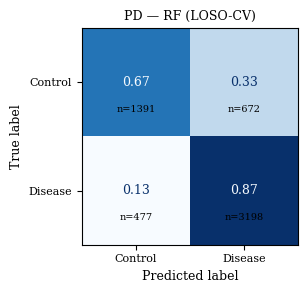

Saved: cm_pd_rf.pdf / .png


In [6]:
# PD confusion matrix — Matplotlib figure for paper (IEEE single-column)
fig, ax = plt.subplots(figsize=(3.5, 3.0))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_pd_norm,
    display_labels=['Control', 'Disease'],
)
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')

ax.set_title('PD — RF (LOSO-CV)', fontsize=9)
ax.set_xlabel('Predicted label', fontsize=9)
ax.set_ylabel('True label', fontsize=9)

# Overlay raw counts in parentheses below normalised values
for i in range(2):
    for j in range(2):
        ax.text(j, i + 0.25, f'n={cm_pd[i, j]}',
                ha='center', va='center', fontsize=7, color='black')

fig.tight_layout()
fig.savefig(FIGURES_PDF / 'cm_pd_rf.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_PNG / 'cm_pd_rf.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: cm_pd_rf.pdf / .png')

## Huntington's Disease (HD) — Highest Separability

HD achieves the highest F1 scores across almost every classifier: RF (0.8995), DT (0.8980), XGBoost (0.8937), KNN (0.8669), LightGBM (0.8702), SVM (0.8524). The choreiform involuntary movements characteristic of HD produce highly distinctive and consistent gait timing abnormalities — large double support time variability, severe bilateral asymmetry — that all tree-based methods capture effectively.

**QDA anomaly:** Despite HD being the most separable condition for tree-based methods, QDA scores its worst result here (0.5799), lower even than PD (0.6406). QDA's class-conditional Gaussian assumption is maximally violated for HD: choreiform movements produce a highly irregular, non-Gaussian gait distribution with heavy tails and multi-modal clusters. This is a meaningful negative result. The disease that produces the most distinctive gait pattern for non-parametric classifiers simultaneously produces the most pathological distribution for parametric classifiers.

**RF depth policy:** RF selects max\_depth=None (fully grown trees) for HD, unlike the depth-limited trees preferred for PD and ALS. HD's multi-dimensional choreiform abnormalities require complex, high-depth decision boundaries to fully characterise.

**XGBoost configuration contrast:** XGBoost selects a deep, slow-learning configuration for HD (max\_depth=7, learning\_rate=0.01, n\_estimators=200) — the opposite of PD's shallow, fast-learning model. Many fine-grained boosting rounds are needed to capture the complexity of HD gait patterns.

In [7]:
# HD confusion matrix
cm_hd = confusion_matrix(y_true_hd, y_pred_hd)
cm_hd_norm = cm_hd.astype(float) / cm_hd.sum(axis=1, keepdims=True)

# The stored predictions come from the authoritative nested LOSO-CV run.
print(f'HD (RF) F1 macro: {f1_score(y_true_hd, y_pred_hd, average="macro"):.4f}')


HD (RF) F1 macro: 0.8995


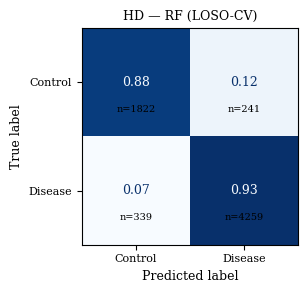

Saved: cm_hd_rf.pdf / .png


In [8]:
# HD confusion matrix — Matplotlib figure for paper
fig, ax = plt.subplots(figsize=(3.5, 3.0))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_hd_norm,
    display_labels=['Control', 'Disease'],
)
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')

ax.set_title('HD — RF (LOSO-CV)', fontsize=9)
ax.set_xlabel('Predicted label', fontsize=9)
ax.set_ylabel('True label', fontsize=9)

for i in range(2):
    for j in range(2):
        ax.text(j, i + 0.25, f'n={cm_hd[i, j]}',
                ha='center', va='center', fontsize=7, color='black')

fig.tight_layout()
fig.savefig(FIGURES_PDF / 'cm_hd_rf.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_PNG / 'cm_hd_rf.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: cm_hd_rf.pdf / .png')

## Amyotrophic Lateral Sclerosis (ALS) — KNN Dominance

ALS produces the most scientifically interesting pattern: KNN (0.8758) outperforms RF (0.7737) by 10 F1 points. This reversal is not present in any other condition.

**Why KNN dominates:** ALS causes progressive motor neuron degeneration leading to weakness and spasticity. Unlike PD's heterogeneous tremor-related variability or HD's involuntary choreiform movements, ALS produces a more stereotyped, constrained gait as motor neurons degenerate. ALS subjects cluster tightly in feature space because the disease imposes a consistent and progressive reduction in gait capacity. KNN exploits this tight clustering directly.

**Manhattan distance selection:** KNN selects L1 (manhattan) distance for ALS rather than euclidean. This is consistent with ALS features having a sparse discriminative structure — the disease primarily affects a subset of gait dimensions (particularly double support and stance time) rather than distributing changes evenly across all 14 features. L1 distance weights individual feature differences more strongly than L2, making it more sensitive to the concentrated abnormality pattern.

**Uniform weighting:** KNN selects uniform weighting (not distance weighting) for ALS, meaning all 11 nearest neighbours contribute equally. This suggests ALS subjects form compact, equally-dense clusters rather than having a distance gradient within the neighbourhood.

**Why RF underperforms for ALS:** RF's random feature subsampling at each split (sqrt(14) ≈ 3.7 features per split) means the signal-bearing features may be excluded from many individual trees. When the discriminative signal is concentrated in a small feature subset, this subsampling introduces noise that KNN, which sees all features for every prediction, avoids.

In [9]:
# ALS confusion matrix
cm_als = confusion_matrix(y_true_als, y_pred_als)
cm_als_norm = cm_als.astype(float) / cm_als.sum(axis=1, keepdims=True)

# The stored predictions come from the authoritative nested LOSO-CV run.
print(f'ALS (KNN) F1 macro: {f1_score(y_true_als, y_pred_als, average="macro"):.4f}')


ALS (KNN) F1 macro: 0.8758


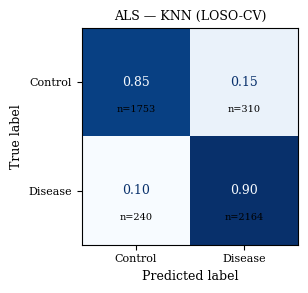

Saved: cm_als_knn.pdf / .png


In [10]:
# ALS confusion matrix — Matplotlib figure for paper
fig, ax = plt.subplots(figsize=(3.5, 3.0))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_als_norm,
    display_labels=['Control', 'Disease'],
)
disp.plot(ax=ax, colorbar=False, cmap='Blues', values_format='.2f')

ax.set_title('ALS — KNN (LOSO-CV)', fontsize=9)
ax.set_xlabel('Predicted label', fontsize=9)
ax.set_ylabel('True label', fontsize=9)

for i in range(2):
    for j in range(2):
        ax.text(j, i + 0.25, f'n={cm_als[i, j]}',
                ha='center', va='center', fontsize=7, color='black')

fig.tight_layout()
fig.savefig(FIGURES_PDF / 'cm_als_knn.pdf', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_PNG / 'cm_als_knn.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: cm_als_knn.pdf / .png')

## Cross-Condition Patterns

**Condition ranking by separability:** HD > ALS > PD. This ordering is consistent with clinical knowledge — HD produces the most distinctive motor abnormalities (choreiform movements), ALS produces a stereotyped progressive weakness pattern, and PD is the most clinically heterogeneous across patients and disease stages.

**ALS KNN anomaly:** The only condition where a distance-based classifier beats RF is ALS. This reflects the stereotyped, spatially compact clustering of ALS subjects in the 14-dimensional feature space. KNN's instance-based classification is directly suited to compact clusters; RF's random feature subsampling misses the concentrated signal. This finding motivates examining ALS separately from HD and PD in the cross-condition transfer analysis.

**QDA anomaly:** QDA achieves its worst performance on HD (0.5799) despite HD being the most separable condition for every other classifier. The choreiform gait distribution that makes HD easy for tree-based methods is maximally non-Gaussian, fatally violating QDA's core assumption. QDA ranks inversely to the other classifiers on HD: best conditions for tree methods are worst for QDA. This is a clean dissociation between parametric and non-parametric inductive biases that should be highlighted in the paper.

**LightGBM num_leaves=31 confirmed by Modal run:** The Modal re-run with num\_leaves ∈ {31, 63} selected num\_leaves=31 in all three conditions. This validates the constraint as a deliberate scientific choice: the dataset (n ≈ 4,467–6,661 strides, 14 features) does not benefit from the larger leaf budget that 63 would provide. The only change from the Modal run was LightGBM PD F1: 0.7211 → 0.7251, a 0.0040 difference consistent with minor grid coverage differences rather than any substantive change.

## Baseline Adequacy for Cross-Condition Transfer (Step 3)

The central question for Step 3 is: do the within-condition F1 scores establish a meaningful performance ceiling against which cross-condition zero-shot transfer can be measured?

**Strong ceiling — HD and ALS:** HD (RF=0.8995) and ALS (KNN=0.8758) establish strong within-condition baselines. These scores are competitive with published results on GAITNDD despite using stricter subject-level LOSO-CV that prevents stride-level data leakage. A classifier transferring into HD or ALS from a different source condition has a clear, defensible ceiling to fall below. The degradation ΔF1 = F1\_within − F1\_cross will be measured against these values.

**Moderate ceiling — PD:** PD (RF=0.7777) establishes a more moderate ceiling. This reflects genuine PD classification difficulty under proper subject-level evaluation, not a methodological weakness. The lower within-condition baseline means ΔF1 for transfers into PD should be interpreted against 0.7777, not against the higher HD or ALS values.

**Transfer evaluation design:** Step 3 trains on the full source condition + Control Group A and tests on the full target condition + Control Group B. Neither the target-condition subjects nor the Group B controls appeared during training. The ΔF1 degradation table will show how much performance is lost when the classifier must generalise across disease-specific gait distributions it was never trained on.

**Hypothesis entering Step 3:** Classifiers best suited to their source condition's gait structure (RF for HD, KNN for ALS) may suffer larger degradation when transferred, because their inductive biases are tuned to source-specific feature distributions. The within-condition results documented here are the reference against which every cell of the degradation table will be measured.